In [1]:
import os
import random
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from torch_geometric.data import Data
from tqdm import tqdm

import barostat_parameters
from graph_utils import prepare_traj
from pressure import compute_total_stress
from simulator_model import Model as VelocityModel
from training_utils import freeze_normalizer
from utils import (
    calc_p_ratio_box_tensor,
    get_rollout,
)


/home/sergey/work/gnn/GNNInverseDesign/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Data

In [2]:
dataset_type = "node_optimized" # "node_optimized" | "stiffness_optimized"
if dataset_type not in {"node_optimized", "stiffness_optimized"}:
    raise ValueError(f"Incorrect data type, expected 'node_optimized' or 'stiffness_optimized', got {dataset_type}. ")

data_dir = os.path.join("./demo_data", f"data_{dataset_type}_40sims.pt")
data = torch.load(data_dir, weights_only=False)

for data_type, sims in data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5}"):
        prepared_sim = prepare_traj(sim, calc_angles=False)
        prepared.append(prepared_sim)
    data[data_type] = prepared

print(f"Train data: {len(data['train'])} sims.")
print(f"FT data:    {len(data['ft'])} sims.")
print(f"Val data:   {len(data['val'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")


test : 100%|██████████| 10/10 [00:00<00:00, 29.83it/s]

Train data: 10 sims.
FT data:    10 sims.
Val data:   10 sims.
Test data:  10 sims.


#### Show $\nu$ distribution

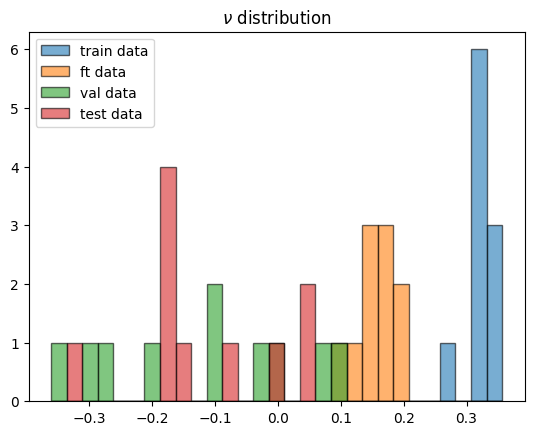

In [3]:
def visualize_nu_disribution(data: Dict):
    ps = {}
    all_values = []

    for data_type, sims in data.items():
        ps[data_type] = [calc_p_ratio_box_tensor(sim).item() for sim in sims]
        all_values.extend(ps[data_type])

    min_val = min(all_values)
    max_val = max(all_values)
    common_bins = np.linspace(min_val, max_val, 30) 

    for data_type, values in ps.items():
        plt.hist(
        values, 
        bins=common_bins, 
        edgecolor='black', 
        alpha=0.6, 
        label=f"{data_type} data"
    )

    plt.title("$\\nu$ distribution")
    plt.legend()
    plt.show()

visualize_nu_disribution(data)


### Initialize pretrained models

In [4]:
mp_layers = 2
mlp = 3
hidden_size = 128
history = 3
device = "cuda"

init_graph = Data(x=torch.ones((100, history*2)), edge_attr=torch.ones((100, 4)))

models = {}

model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
model.load_checkpoint(f"./trained_models/{dataset_type}/OST/model_h{history}_nl{mp_layers}_mlp{mlp}_epochs100.pt")
model = freeze_normalizer(model)
models[f"h{3} ost"] = model

model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
model.load_checkpoint(f"./trained_models/{dataset_type}/MST/model_h{history}_nl{mp_layers}_mlp{mlp}_epochs100.pt")
model = freeze_normalizer(model)
models[f"h{3} mst"] = model

for i, model_name in enumerate(models.keys()):
    print(f"{i+1}. Model {model_name}.")

1. Model h3 ost.
2. Model h3 mst.


### Testing models

#### Test model performance

In [ ]:
factors = [(sim[4].box_tensor[0]/sim[3].box_tensor[0]).item() for sim in data["test"]]
mean_factor = sum(factors)/len(factors)
mean_factor

0.9999799966812134


In [6]:
num_steps = 50
model_results = {}
test_models = models

barostat_config = barostat_parameters.node_optimizated if dataset_type == "node_optimized" else barostat_parameters.stiff_optimized

name_len = max([len(n) for n in test_models.keys()])+1 

for model_name, model in test_models.items():
    model.eval()

    history = int(model_name[1])
    target_idx = num_steps + history + 1
    results = {
        "gt_box_velocity": [],
        "pred_box_velocity": [],
        "final_mse": [],
        "mse": [],
        "est_p": [],
        "pred_p": [],
        "gt_est_p": [],
        "gt_p": [],
        "gt_box": [],
        "pred_box": [],
        "gt_forces": [],
        "pred_forces": [],
        "gt_pressure": [],
        "pred_pressure": [],
    }

    with torch.no_grad():
        for val_sim in tqdm(data['val'][:30] + data['test'][:30] + data['train'][:30] + data['ft'][:30], desc=f"Model {model_name:<{name_len}}"):

            # This block computes dumping period (N MD steps in 1 dump step)        
            sim_strain = (val_sim[1].box.x - val_sim[-1].box.x) / val_sim[0].box.x
            assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
            dump_period = int(assumed_rollout_length / len(val_sim)) + 1
                        
            input_graphs = [g.cpu().detach() for g in val_sim[: history + 1]]

            rollout = get_rollout(
                input_graphs=input_graphs,
                gnn_simulator=model,
                gnn_history=history,
                num_steps=num_steps,
                barostat_config=barostat_config,
                device="cuda"
            )

            # Compare Predicted Position vs Ground Truth Position
            pos_mse = torch.nn.functional.mse_loss(rollout[-1].pos.cpu(), val_sim[target_idx].to(device).pos.cpu()).item()
            results["final_mse"].append(pos_mse)
            pos_mse = [torch.nn.functional.mse_loss(rollout[i].pos.cpu(), val_sim[i].to(device).pos.cpu()).item() for i in range(len(rollout))]
            results["mse"].append(pos_mse)
            
            pred_p = calc_p_ratio_box_tensor(rollout).item()
            results["pred_p"].append(pred_p)
            gt_p = calc_p_ratio_box_tensor(val_sim[:target_idx]).item()
            results["gt_p"].append(gt_p)

            pred_box = [g.box_tensor.cpu() for g in rollout]
            results["pred_box"].append(pred_box)
            gt_box = [g.box_tensor.cpu() for g in val_sim[: len(rollout)]]
            results["gt_box"].append(gt_box)

            gt_pressure = torch.stack([compute_total_stress(g, r0=input_graphs[0].edge_attr[:, -2].to(g.x.device), temperature=1e-7).cpu() for g in val_sim[: len(rollout)]], dim=0)
            results['gt_pressure'].append(gt_pressure)
            pred_pressure = torch.stack([compute_total_stress(g, r0=input_graphs[0].edge_attr[:, -2].to(g.x.device), temperature=1e-7).cpu() for g in rollout], dim=0)
            results["pred_pressure"].append(pred_pressure)

    model_results[model_name] = results

Model h3 mst : 100%|██████████| 40/40 [00:05<00:00,  7.94it/s]


In [7]:
params = {
    'font.size': 8,                 # Base font size
    'axes.labelsize': 8,            # Axis labels (e.g., nu_gt)
    'axes.titlesize': 8,            # Subplot titles
    'xtick.labelsize': 7,           # Tick numbers
    'ytick.labelsize': 7,   
    'legend.fontsize': 6,           # Make legend smaller to fit
    'lines.markersize': 4,          # Reduce scatter dot size
    'figure.figsize': (3.33, 3.33), # Your target size
    'figure.dpi': 200,              # High DPI for clear viewing
    'font.family': 'serif',         # Matches most LaTeX/Paper fonts
}
plt.rcParams.update(params)


#### Parity plots for GT and predicted $\nu$

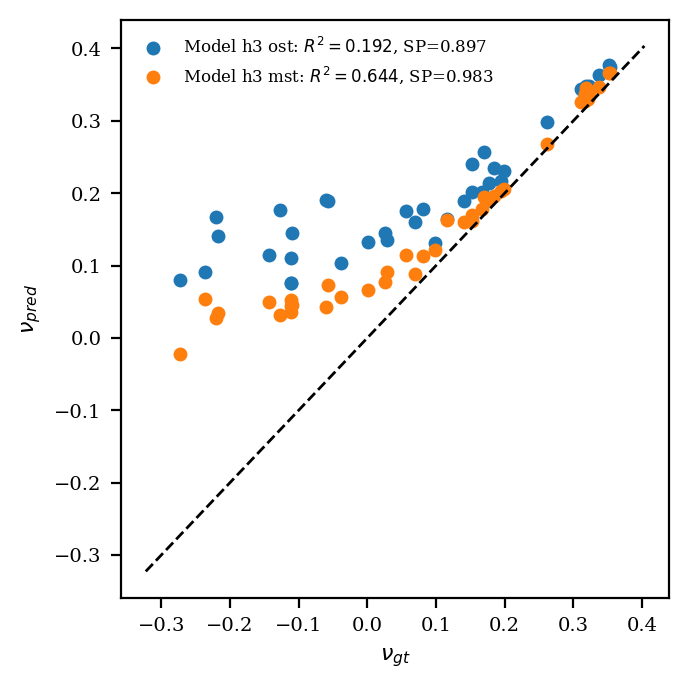

In [8]:
fig, ax = plt.subplots(1, 1, layout="constrained")

line = (min(results["gt_p"]) - 0.05, max(results["gt_p"]) + 0.05)
ax.plot(line, line, color="black", linewidth=1, linestyle='--')

for model_name, results in model_results.items():

    r2 = r2_score(results['gt_p'], results['pred_p'])
    res = spearmanr(results["gt_p"], results["pred_p"])
    sp = res.statistic
    
    label_text = f"Model {model_name}: $R^2={r2:.3f}$, SP={sp:.3f}"
    ax.scatter(results["gt_p"], results["pred_p"], label=label_text)
    
ax.legend(frameon=False, loc='best')
ax.set_xlabel(r"$\nu_{gt}$")
ax.set_ylabel(r"$\nu_{pred}$")


plt.show()

#### MSE as a function of strain

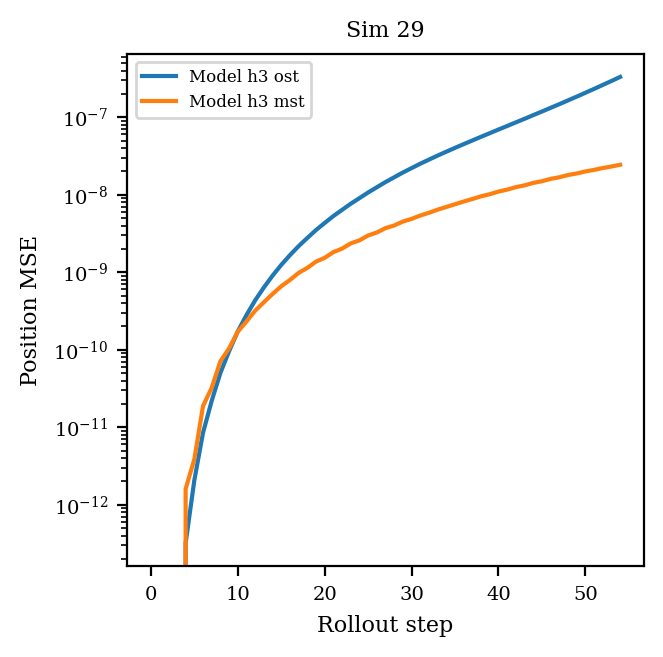

In [9]:
rand_sim = random.randint(0, len(results['mse'])-1)
for model_name, results in model_results.items():
    plt.plot(results["mse"][rand_sim], label=f"Model {model_name}")

plt.legend()
plt.yscale('log')
plt.title(f"Sim {rand_sim}")
plt.xlabel('Rollout step')
plt.ylabel('Position MSE')
plt.show()

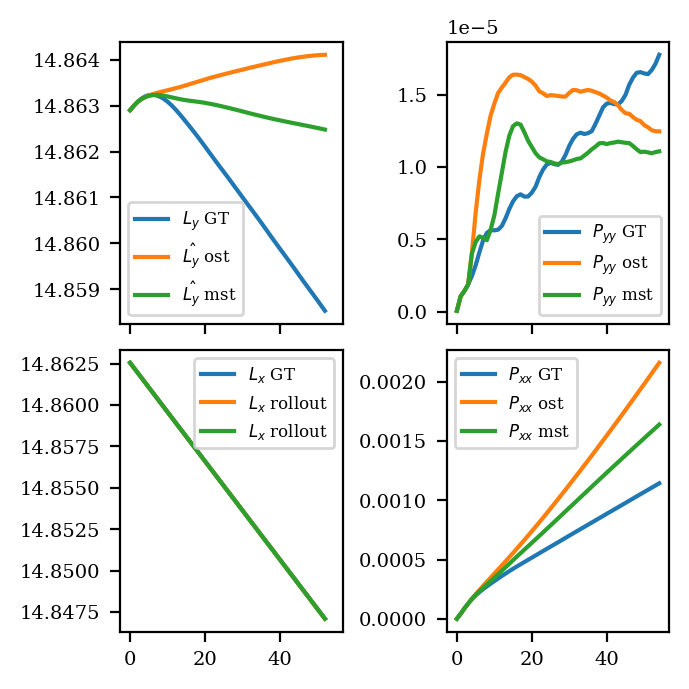

In [10]:
rand = random.randint(0, len(results) - 1)

fig, ax = plt.subplots(2, 2, layout="constrained", sharex=True)

box_y_true = [model_results["h3 ost"]["gt_box"][rand][i][1].item() for i in range(1, len(rollout) - 1)]
box_x_true = [model_results["h3 ost"]["gt_box"][rand][i][0].item() for i in range(1, len(rollout) - 1)]

pressure_gt = results["gt_pressure"][rand]

ax[0][0].plot(box_y_true, label="$L_y$ GT")
ax[1][0].plot(box_x_true, label="$L_x$ GT")
ax[0][1].plot(pressure_gt[:, 1], label="$P_{{yy}}$ GT")
ax[1][1].plot(pressure_gt[:, 0], label="$P_{{xx}}$ GT")


for model_name, results in model_results.items():


    box_y_roll = [results["pred_box"][rand][i][1].item() for i in range(1, len(rollout) - 1)]
    box_x_roll = [results["pred_box"][rand][i][0].item() for i in range(1, len(rollout) - 1)]

    pressure_roll = results["pred_pressure"][rand]

    ax[0][0].plot(box_y_roll, label=f"$\\hat{{L_y}}$ {model_name.split()[1]}")
    ax[0][0].legend()

    ax[1][0].plot(box_x_roll, label="$L_x$ rollout")
    ax[1][0].legend()

    ax[0][1].plot(pressure_roll[:, 1], label=f"$P_{{yy}}$ {model_name.split()[1]}")
    ax[0][1].legend()
    
    ax[1][1].plot(pressure_roll[:, 0], label=f"$P_{{xx}}$ {model_name.split()[1]}")
    ax[1][1].legend()

plt.show()